In [1]:
import pandas as pd
import collections
import plotnine as p9
p9.theme_set(p9.theme_bw)

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE # umap doesn't load :(

import time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import calcutta
import scipy.sparse as sp
import scipy.io
import re
import calcutta
from importlib import reload
reload(calcutta)

def sparse_sum(x, dim):
    return np.squeeze(np.asarray(x.sum(dim)))


## Check coverage per cell

This code should all also work when using t2t_dedup (i.e. isoform level counts). 

In [7]:
data_dir = Path("/gpfs/commons/groups/knowles_lab/data/sc/splitpool/microglia_less_mice")
#salmon_dir = data_dir / "salmon_spliceu" / "out_permit_known" / "quant_t2t_dedup" 
salmon_dir = data_dir / "salmon_per_sublib"# / "out_permit_known" / "quant_spliceu_t2g"

cells_meta = {}
for srrdir in salmon_dir.iterdir(): 
    cells_meta[srrdir.name] = pd.read_csv(srrdir / "out_permit_known" / "quant_spliceu_t2g" / "featureDump.txt", sep = "\t")
    cells_meta[srrdir.name]["SRR"] = srrdir.name
    
cells_meta = pd.concat(cells_meta.values(), axis=0)
#cells_meta = pd.read_csv(salmon_dir / "featureDump.txt", sep = "\t")
#cells_meta.shape # 192k cells in OG split-seq, 79k in microglia_less (30k according to paper, but these might be "half cells")
# 744k when using known BCs (!) for microglialess

Text(0.5, 0, 'log10(deduped reads)')

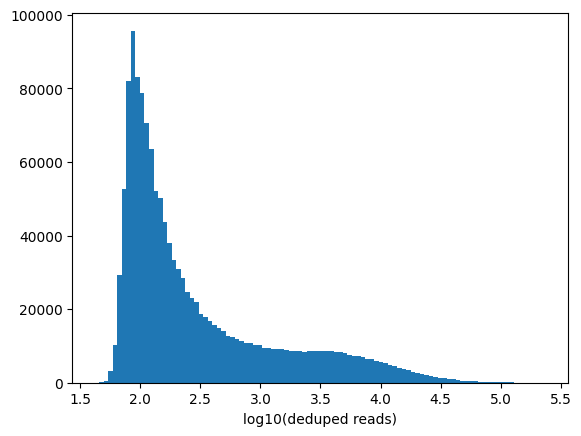

In [9]:
plt.hist(np.log10(cells_meta.DeduplicatedReads), 100)
plt.xlabel("log10(deduped reads)")

I think just the fat right tail are the real cells. 

In [22]:
# get the Parse/V2 barcodes (thanks Scott!) 
parse_meta_dir = Path("/gpfs/commons/groups/knowles_lab/data/sc/splitpool/Parse_meta")
ligation_BCs_v2 = pd.read_csv(parse_meta_dir / "Parse_ligation_barcodes.txt", sep = "\t", header = None)
ligation_BCs_v2 = ligation_BCs_v2[0].tolist() 
ligation_BCs_v2[:5]

['AACGTGAT', 'AAACATCG', 'ATGCCTAA', 'AGTGGTCA', 'ACCACTGT']

In [23]:
rt_BCs_v2 = pd.read_csv(parse_meta_dir / "Parse_RT_barcodes.txt", sep = "\t", header = None)
rt_BCs_v2 = rt_BCs_v2[0].tolist() 
len(rt_BCs_v2) # 96 barcodes (the order matters!)

96

## Align with preprocessed data

The paper provided preprocessed data which we align our analysis with here: 

In [11]:
preproc_BCs_id = [ g.strip() for g in open(data_dir / "GSM5693472_barcodes.tsv","r").readlines() ]
preproc_BCs = [ g.split("_")[0] for g in preproc_BCs_id ]
preproc_BCs_id[:5] # these are [rnd3 BC][rnd2 BC]_[rnd1 well ID]_[sublib ID]

['TTCACGCAACGCTCGA_7_1',
 'AAGACGGAAACGCTTA_8_1',
 'CCATCCTCACCTCCAA_30_1',
 'CCTCTATCCGACTGGA_24_1',
 'GCTAACGACAAGACTA_23_1']

In [12]:
RT_BC_index = [ int(g.split("_")[1]) for g in preproc_BCs_id ]
set(RT_BC_index) == set(range(48)) # 48 rnd1 wells

True

In [13]:
sublib_index = [ g.split("_")[2] for g in preproc_BCs_id ]
set(sublib_index)  # 8 sublibs

{'1', '2', '3', '4', '5', '6', '7', '8'}

In [14]:
preproc_cellmeta = pd.read_csv(data_dir / "GSM5693472_cell_metadata.txt.gz", sep = "\t")
preproc_cellmeta.head()

,nCount_RNA,nFeature_RNA,sample,rnd1_well,rnd2_well,rnd3_well,sublibrary,RNA.Nuclei.Group,Age,Sex,Sac,Dissection.Batch,DX,RIN,percent.mt,class,cluster_name,clusternum_anno,clusters_4conditions,cellchat_clusters
0,19978,4489,E-7,7,20,67,ACTTGA,Group1,5.115,M,8/19/2020,2,5xFIRE + PBS,8.8,0.020022,EX,EX cortical,8-EX cortical L5,NaN,EX cortical
1,19974,4923,F-7,8,14,15,ACTTGA,Group2,5.082,M,8/12/2020,2,5xFIRE + transplant,8.3,0.590768,INH,INH midbrain,0-INH midbrain,NaN,INH midbrain
2,19966,4589,C-6,30,19,84,ACTTGA,Group4,5.049,M,11/14/2019,1,FIRE,7.6,0.030051,EX,EX thalamus,16-EX thalamus,15-EX thalamus,EX thalamus
3,19949,4476,F-2,24,40,87,ACTTGA,Group4,5.049,F,8/12/2020,2,5xFIRE + transplant,8.7,0.060153,EX,EX cortical,8-EX cortical L5,NaN,EX cortical
4,19941,5197,F-5,23,46,51,ACTTGA,Group3,5.148,M,7/23/2020,2,5xFIRE + transplant,8.3,0.235695,VLMC,VLMC,27-VLMC,NaN,VLMC


In [15]:
preproc_cellmeta.rnd1_well.max() 
# only 48 entries (zero indexed!) compared to 96 for rnd2 and rnd3. So hex+polydT already combined. 

47

In [16]:
preproc_cellmeta["rnd3_BC"] = [ g[:8] for g in preproc_BCs ]
preproc_cellmeta["rnd2_BC"] = [ g[8:] for g in preproc_BCs ]
preproc_cellmeta["sublib_BC"] = [ g.split("_")[2] for g in preproc_BCs_id ]

In [17]:
tab_BC2 = preproc_cellmeta.groupby(["rnd2_BC","rnd2_well"]).size() # correct, and gives mapping
tab_BC2 = tab_BC2.reset_index()
tab_BC2 = tab_BC2.sort_values("rnd2_well")

In [19]:
tab_BC3 = preproc_cellmeta.groupby(["rnd3_BC","rnd3_well"]).size() # correct, and gives mapping (think ordering is what I have)
tab_BC3 = tab_BC3.reset_index()
tab_BC3 = tab_BC3.sort_values("rnd3_well")
tab_BC3.head()

,rnd3_BC,rnd3_well,0
4,AACGTGAT,0,537
0,AAACATCG,1,528
36,ATGCCTAA,2,542
32,AGTGGTCA,3,523
18,ACCACTGT,4,543


In [20]:
preproc_cellmeta.groupby(["rnd2_BC","rnd2_well"]).size()

rnd2_BC   rnd2_well
AAACATCG  1            574
AACAACCA  12           535
AACCGAGA  13           520
AACGCTTA  14           524
AACGTGAT  0            541
                      ... 
TGAAGAGA  63           497
TGGAACAA  64           534
TGGCTTCA  65           571
TGGTGGTA  66           553
TTCACGCA  67           554
Length: 96, dtype: int64

In [21]:
preproc_cellmeta.groupby(["sublibrary","sublib_BC"]).size() # correct

sublibrary  sublib_BC
ACTTGA      1            4570
AGTCAA      2            8132
AGTTCC      3            7749
CAGATC      4            4777
CTTGTA      5            7613
GATCAG      6            4992
GGCTAC      7            6702
TAGCTT      8            6792
dtype: int64

In [32]:
ligation_BCs_v2 = np.array(ligation_BCs_v2).astype(str)
rt_BCs_v2 = np.array(rt_BCs_v2).astype(str)

# build the full cell BCs for the preproc data
rnd3_rnd2 = np.char.add( 
    ligation_BCs_v2[ preproc_cellmeta.rnd3_well.to_numpy() ],
    ligation_BCs_v2[ preproc_cellmeta.rnd2_well.to_numpy() ] )

preproc_cellmeta["full_BC_polydT"] = np.char.add( rnd3_rnd2, rt_BCs_v2[ preproc_cellmeta.rnd1_well.to_numpy() ] )
preproc_cellmeta["full_BC_ranhex"] = np.char.add( rnd3_rnd2, rt_BCs_v2[48:][ preproc_cellmeta.rnd1_well.to_numpy() ] )

In [36]:
polydT_merge = pd.merge(cells_meta, preproc_cellmeta, left_on = "CB", right_on = "full_BC_polydT", how = "inner")
ranhex_merge = pd.merge(cells_meta, preproc_cellmeta, left_on = "CB", right_on = "full_BC_ranhex", how = "inner")

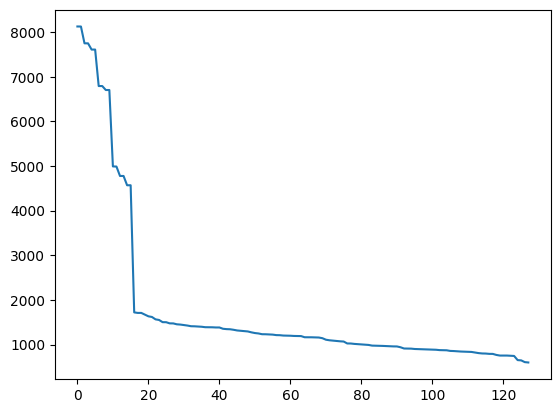

In [66]:
polydT_sublib_SRR = polydT_merge.groupby(['sublibrary','SRR']).size().reset_index(name="counts").sort_values(by="counts", ascending = False)
plt.plot(np.arange(len(polydT_sublib_SRR)),polydT_sublib_SRR.counts)

In [67]:
polydT_sublib_SRR.head(20) # there 16 SRRs and 8 sublibs

,sublibrary,SRR,counts
22,AGTCAA,SRR16966889,8125
29,AGTCAA,SRR16966896,8124
46,AGTTCC,SRR16966897,7748
39,AGTTCC,SRR16966890,7747
69,CTTGTA,SRR16966888,7608
76,CTTGTA,SRR16966895,7608
115,TAGCTT,SRR16966886,6791
122,TAGCTT,SRR16966893,6791
107,GGCTAC,SRR16966894,6702
100,GGCTAC,SRR16966887,6702


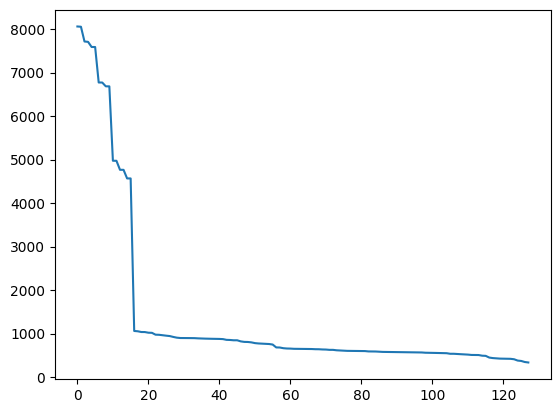

In [68]:
ranhex_sublib_SRR = ranhex_merge.groupby(['sublibrary','SRR']).size().reset_index(name="counts").sort_values(by="counts", ascending = False)
plt.plot(np.arange(len(ranhex_sublib_SRR)),ranhex_sublib_SRR.counts)

In [69]:
ranhex_sublib_SRR.head(20)

,sublibrary,SRR,counts
22,AGTCAA,SRR16966889,8058
29,AGTCAA,SRR16966896,8052
46,AGTTCC,SRR16966897,7713
39,AGTTCC,SRR16966890,7705
69,CTTGTA,SRR16966888,7587
76,CTTGTA,SRR16966895,7586
122,TAGCTT,SRR16966893,6771
115,TAGCTT,SRR16966886,6770
107,GGCTAC,SRR16966894,6683
100,GGCTAC,SRR16966887,6682


In [71]:
polydT_sublib_SRR_valid = polydT_sublib_SRR.head(16)

In [72]:
ranhex_sublib_SRR_valid = ranhex_sublib_SRR.head(16)

In [75]:
merged = pd.merge(polydT_sublib_SRR_valid, ranhex_sublib_SRR_valid, on = "SRR")
merged.sublibrary_x == merged.sublibrary_y

0     True
1     True
2     True
3     True
4     True
5     True
6     True
7     True
8     True
9     True
10    True
11    True
12    True
13    True
14    True
15    True
dtype: bool

In [89]:
sublib_SRR_map = polydT_sublib_SRR_valid.pivot_table(index=polydT_sublib_SRR_valid.groupby('sublibrary').cumcount(), columns='sublibrary', values='SRR', aggfunc='first')
sublib_SRR_map = sublib_SRR_map.transpose().reset_index()
sublib_SRR_map

,sublibrary,0,1
0,ACTTGA,SRR16966891,SRR16966884
1,AGTCAA,SRR16966889,SRR16966896
2,AGTTCC,SRR16966897,SRR16966890
3,CAGATC,SRR16966898,SRR16966883
4,CTTGTA,SRR16966888,SRR16966895
5,GATCAG,SRR16966885,SRR16966892
6,GGCTAC,SRR16966894,SRR16966887
7,TAGCTT,SRR16966886,SRR16966893


In [90]:
sublib_SRR_map.to_csv(data_dir / "sublib_SRR_map.tsv", sep = "\t", header=False, index=False)